Shape del dataset: (1797, 65)

Prime righe del DataFrame:


,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4



Silhouette Score con K=10: 0.182
Interpretazione: clustering debole o poco separato

Confronto Silhouette Score per diversi K:


,k,silhouette_score
0,2,0.118328
1,3,0.126495
2,4,0.128015
3,5,0.136208
4,6,0.150688
5,7,0.164026
6,8,0.178709
7,9,0.189073
8,10,0.182385
9,11,0.183251


Miglior K secondo il Silhouette Score: 9
Score migliore: 0.189


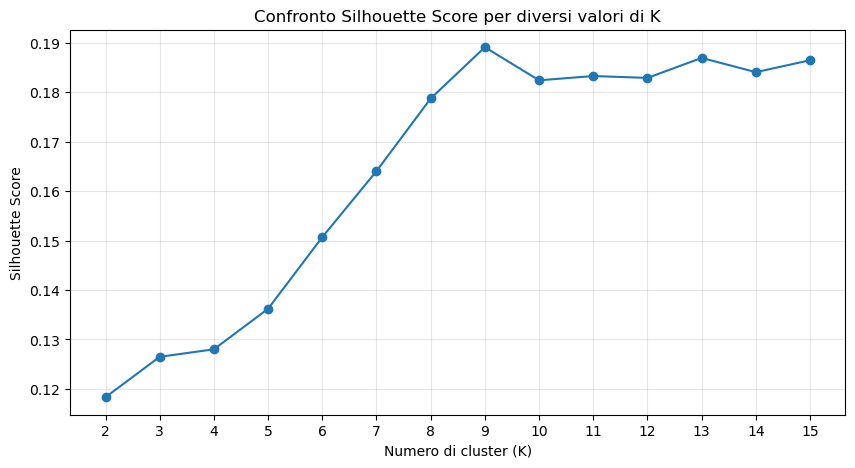

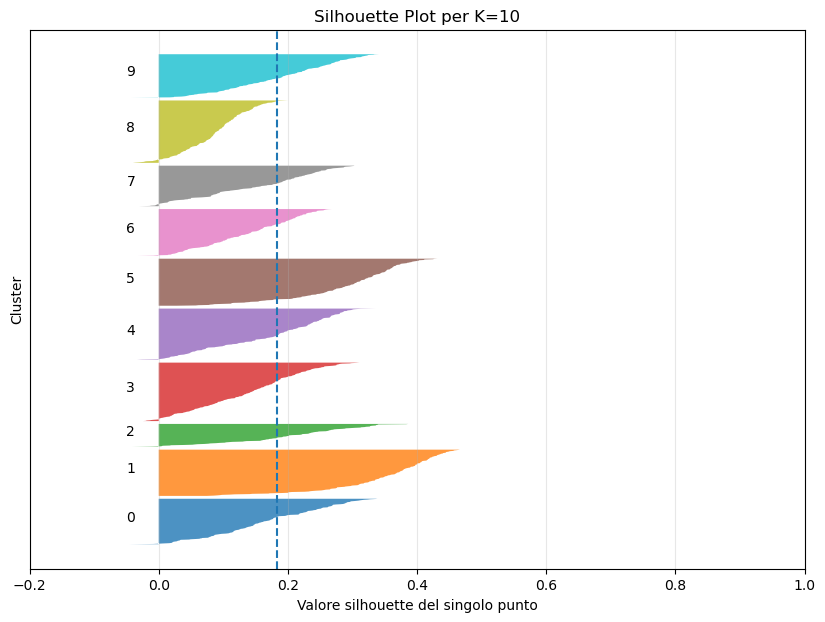


Conclusione finale
--------------------------------------------------
Con K=10, il Silhouette Score medio è: 0.182
Il miglior K provato nel range 2-15 è: 9 con score 0.189
La scelta K=10 è sensata rispetto alle classi reali del dataset,
ma non è necessariamente la migliore dal punto di vista del Silhouette Score.


In [1]:
# ============================================================
# 3_612 - Silhouette Score
# Dataset: Digits
# Algoritmo: K-Means
# Obiettivo:
# - applicare K-Means al dataset digits
# - calcolare il Silhouette Score globale
# - estendere l'analisi con confronto tra diversi K
# - visualizzare il silhouette plot
# ============================================================

# =========================
# 1. Import librerie
# =========================
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import load_digits
from sklearn.metrics import silhouette_score, silhouette_samples


# =========================
# 2. Caricamento dataset
# =========================
# load_digits() restituisce:
# - data.data   -> matrice delle feature
# - data.target -> etichette reali (0-9)
# Ogni immagine è rappresentata da 64 feature (8x8 pixel appiattiti).
data = load_digits()

X = data.data
y = data.target

# Creiamo un DataFrame per ispezione e leggibilità.
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

print("Shape del dataset:", df.shape)
print("\nPrime righe del DataFrame:")
display(df.head())


# =========================
# 3. Clustering base con K=10
# =========================
# Scegliamo K=10 perché il dataset contiene cifre da 0 a 9.
# Attenzione: questa è una scelta guidata dalla conoscenza del dataset,
# non ancora una prova che sia il K ottimale dal punto di vista geometrico.
K = 10

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X)


# =========================
# 4. Calcolo del Silhouette Score globale
# =========================
# Il Silhouette Score misura la qualità del clustering:
# - valori alti  -> cluster compatti e separati
# - valori ~ 0   -> cluster sovrapposti / poco chiari
# - valori < 0   -> possibili assegnazioni scorrette
silhouette = silhouette_score(X, y_pred)

print(f"\nSilhouette Score con K={K}: {silhouette:.3f}")


# =========================
# 5. Interpretazione rapida automatica
# =========================
if silhouette >= 0.70:
    giudizio = "clustering molto buono"
elif silhouette >= 0.50:
    giudizio = "clustering buono"
elif silhouette >= 0.25:
    giudizio = "clustering discreto ma non fortissimo"
else:
    giudizio = "clustering debole o poco separato"

print("Interpretazione:", giudizio)


# =========================
# 6. Confronto tra diversi valori di K
# =========================
# Questa parte estende l'esercizio:
# proviamo diversi numeri di cluster e confrontiamo il Silhouette Score.
results = []

for k in range(2, 16):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)

    results.append({
        "k": k,
        "silhouette_score": score
    })

results_df = pd.DataFrame(results)

print("\nConfronto Silhouette Score per diversi K:")
display(results_df)

best_row = results_df.loc[results_df["silhouette_score"].idxmax()]
best_k = int(best_row["k"])
best_score = best_row["silhouette_score"]

print(f"Miglior K secondo il Silhouette Score: {best_k}")
print(f"Score migliore: {best_score:.3f}")


# =========================
# 7. Grafico: Silhouette Score vs K
# =========================
plt.figure(figsize=(10, 5))
plt.plot(results_df["k"], results_df["silhouette_score"], marker="o")
plt.title("Confronto Silhouette Score per diversi valori di K")
plt.xlabel("Numero di cluster (K)")
plt.ylabel("Silhouette Score")
plt.xticks(results_df["k"])
plt.grid(True, alpha=0.3)
plt.show()


# =========================
# 8. Silhouette plot per K=10
# =========================
# Calcoliamo il valore silhouette per ogni singolo punto.
sample_silhouette_values = silhouette_samples(X, y_pred)

fig, ax = plt.subplots(figsize=(10, 7))

y_lower = 10

for cluster_id in range(K):
    cluster_values = sample_silhouette_values[y_pred == cluster_id]
    cluster_values.sort()

    cluster_size = cluster_values.shape[0]
    y_upper = y_lower + cluster_size

    ax.fill_betweenx(
        y=range(y_lower, y_upper),
        x1=0,
        x2=cluster_values,
        alpha=0.8
    )

    # Etichetta del cluster al centro della fascia
    ax.text(-0.05, y_lower + 0.5 * cluster_size, str(cluster_id))

    y_lower = y_upper + 10

# Linea verticale dello score medio globale
ax.axvline(x=silhouette, linestyle="--", linewidth=1.5)

ax.set_title(f"Silhouette Plot per K={K}")
ax.set_xlabel("Valore silhouette del singolo punto")
ax.set_ylabel("Cluster")
ax.set_yticks([])
ax.set_xlim([-0.2, 1.0])
ax.grid(True, axis="x", alpha=0.3)

plt.show()


# =========================
# 9. Conclusione stampata
# =========================
print("\nConclusione finale")
print("-" * 50)
print(f"Con K={K}, il Silhouette Score medio è: {silhouette:.3f}")
print(f"Il miglior K provato nel range 2-15 è: {best_k} con score {best_score:.3f}")

if best_k == K:
    print("La scelta K=10 risulta coerente anche rispetto al confronto con altri K.")
else:
    print("La scelta K=10 è sensata rispetto alle classi reali del dataset,")
    print("ma non è necessariamente la migliore dal punto di vista del Silhouette Score.")